In [2]:
# Loading libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [3]:
# Loading dataset
df = pd.read_csv(r"C:\Coding_Samurai_Internship\Titanic_train.csv")

# Display first 5 rows
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare  
0      0         A/5 21171   7.2500  
1      0          PC 17599  71.2833  
2      0  STON/O2. 3101282   7.9250  
3      0            113803  53.1000  
4      0            373450   8.0500  


In [6]:
print(df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'FamilySize']


In [7]:
# Fill missing age values using median age
df["Age"] = df["Age"].fillna(df["Age"].median())

In [8]:
# Create IsAlone feature from FamilySize
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

In [10]:
# Extract passenger title from the Name column
df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\\.")

# Replace uncommon titles with 'Other' to reduce categories
df["Title"] = df["Title"].replace(
    ["Dr","Rev","Col","Major","Lady","Countess",
     "Jonkheer","Sir","Don","Capt"],
    "Other"
)

In [11]:
# Convert categorical gender values into numeric form
df["Sex"] = df["Sex"].map({
    "male":0,
    "female":1
})

In [12]:
# Convert title categories into numbers
title_map = {
    "Mr":0,
    "Miss":1,
    "Mrs":2,
    "Master":3,
    "Other":4
}
df["Title"] = df["Title"].map(title_map)
df["Title"] = df["Title"].fillna(4)

In [13]:
# Drop columns not required for prediction
df.drop(
    ["PassengerId","Name","Ticket"],
    axis=1,
    inplace=True
)

In [14]:
# Separate input features and target variable
X = df.drop("Survived", axis=1)
y = df["Survived"]
print(X.columns)

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize',
       'IsAlone', 'Title'],
      dtype='object')


In [15]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
# Train Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [17]:
# Generate predictions on test data
y_pred = model.predict(X_test)

In [18]:
# Evaluate model accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 78.77 %


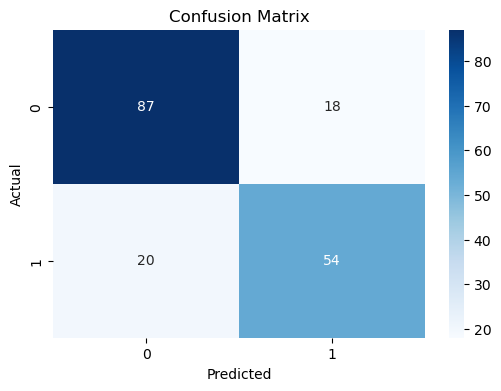

In [19]:
# Visualize model performance using confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [20]:
# Analyze which features influence predictions most
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance = importance.sort_values(
    by="Coefficient",
    ascending=False
)

print(importance)

      Feature  Coefficient
1         Sex     2.113462
8       Title     0.558769
5        Fare     0.004625
2         Age    -0.031323
4       Parch    -0.074551
3       SibSp    -0.245927
6  FamilySize    -0.295186
7     IsAlone    -0.500479
0      Pclass    -0.781281


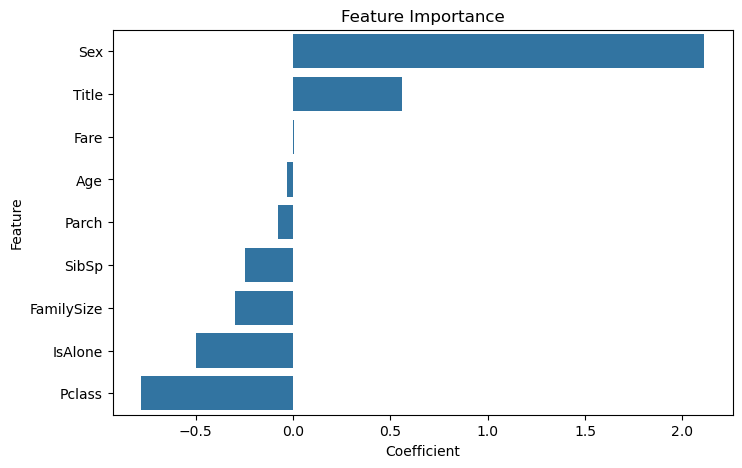

In [21]:
# Create a bar chart to compare feature importance values
plt.figure(figsize=(8,5))
sns.barplot(
    x="Coefficient",
    y="Feature",
    da
    ta=importance
)
plt.title("Feature Importance")
plt.show()